In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


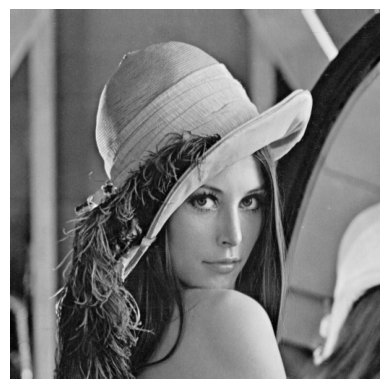

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/lena.mat')['lena']

# plot image
plt.imshow(img, cmap='gray')
plt.axis('off');


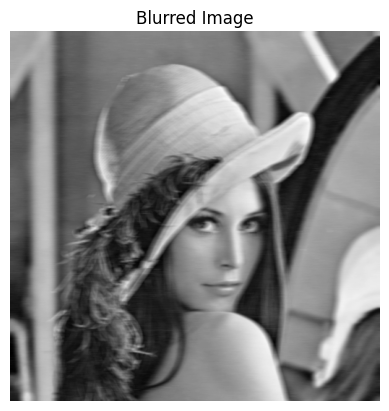

In [ ]:
import cv2

kernel_size = 10
kernel_h = np.zeros((kernel_size, kernel_size))
kernel_h[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
kernel_h /= kernel_size

# Apply the horizontal kernel
img_b = cv2.filter2D(img, -1, kernel_h)

# plot image
plt.title('Blurred Image')
plt.imshow(img_b, cmap='gray')
plt.axis('off');


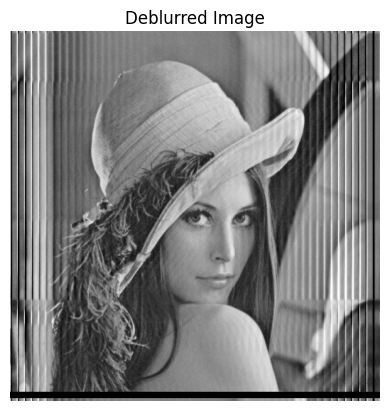

In [ ]:
import numpy as np
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def inverse_filter_deblur(blurred_image, psf):

    epsilon = 1e-3 # Small value to prevent division by zero

    #blurred_image_float = blurred_image.astype(float)
    #psf_float = psf.astype(float)

    img_rows, img_cols = blurred_image.shape
    psf_rows, psf_cols = psf.shape

    padded_rows = img_rows + psf_rows - 1
    padded_cols = img_cols + psf_cols - 1

    # Create new arrays filled with zeros
    padded_image = np.zeros((padded_rows, padded_cols), dtype=blurred_image.dtype)
    padded_psf = np.zeros((padded_rows, padded_cols), dtype=psf.dtype)

    # Place the original image and PSF into the top-left corner
    padded_image[:img_rows, :img_cols] = blurred_image
    padded_psf[:psf_rows, :psf_cols] = psf

    # Compute FFT of the padded blurred image and the padded PSF
    fft_blurred = fft2(padded_image)
    fft_psf = fft2(padded_psf)

    # Apply the inverse filter in the frequency domain
    # Add epsilon to the denominator to prevent division by zero
    fft_deblurred = fft_blurred* fft_psf.conjugate() / ((abs(fft_psf))**2 + epsilon)

    # Compute inverse FFT to get the deblurred image in the spatial domain
    deblurred_image = np.real(ifft2(fft_deblurred))

    # Normalize the deblurred image to the original range (e.g., 0-255 for 8-bit images)
    deblurred_image = np.clip(deblurred_image, 0, 255).astype(np.uint8)

    return deblurred_image

# Call the function with your image and kernel
deblurred_image = inverse_filter_deblur(img_b, kernel_h)

# Display the image
plt.title("Deblurred Image")
plt.imshow(deblurred_image, cmap='gray')
plt.axis('off')
plt.show() # This line makes the plot appear